C:\Users\sara9\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Params: {'subsample': 0.6, 'n_estimators': 300, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.01}
Best CV R²: 0.4600240679475075

[GBR - Train]
RMSE: 1.6483
MAE : 1.3073
R²  : 0.6483

[GBR - Test]
RMSE: 2.0724
MAE : 1.5807
R²  : 0.4124

Overfitting Gap (Train - Test R²): 0.2359


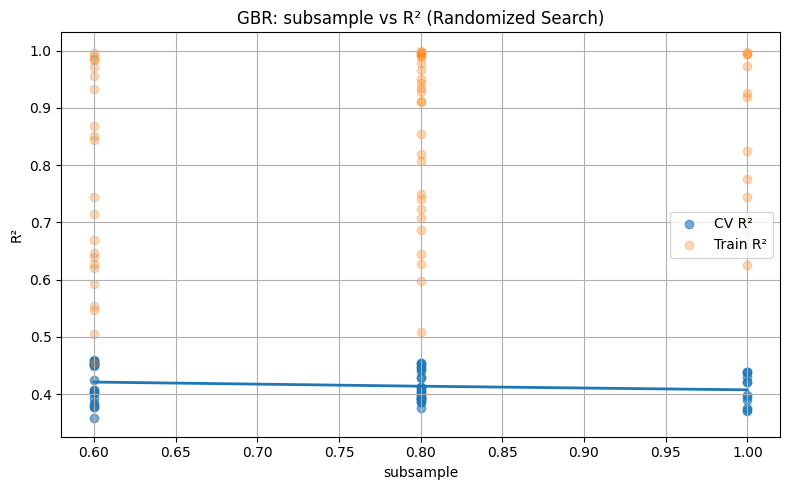

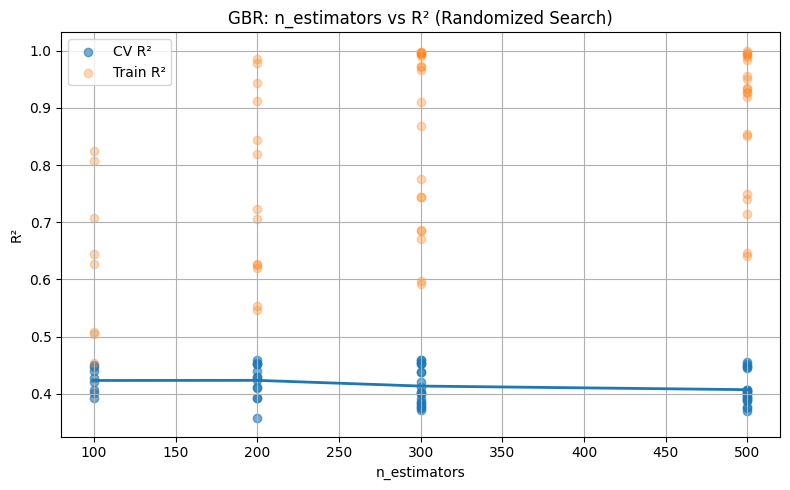

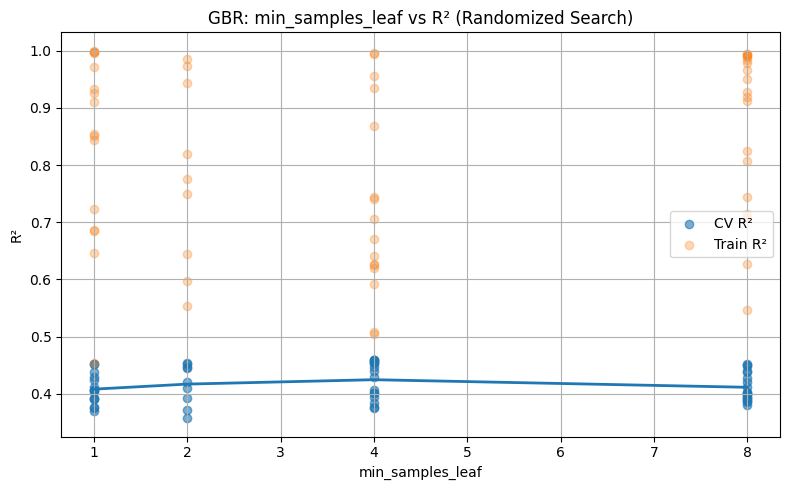

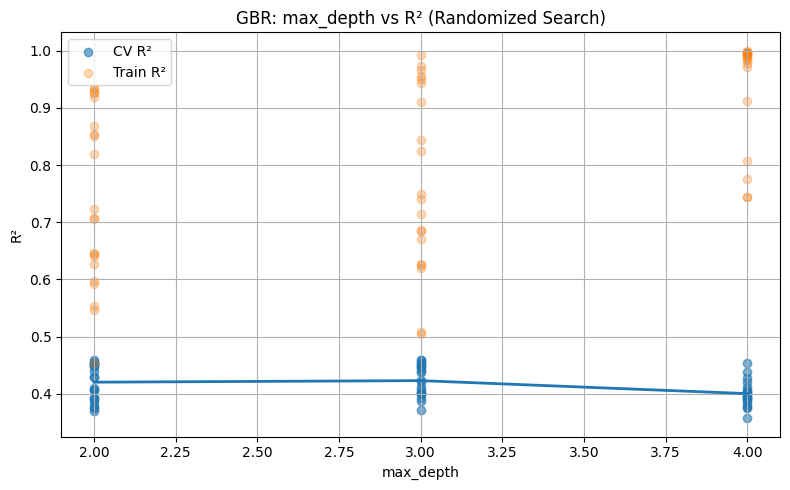

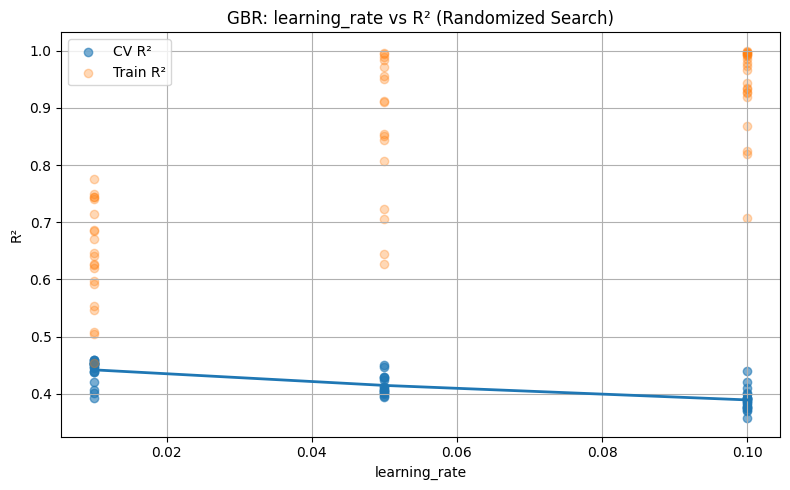

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold # 💡 匯入 RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -----------------------
# 1) 讀資料 & 篩選
# -----------------------
df = pd.read_csv('NBA_Normalized_Final.csv')
bool_cols = ['Is_Undrafted', 'Pos_PG', 'Pos_C', 'Pos_SG', 'Pos_SF', 'Pos_PF']

for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})

df_g = df[(df['season'] > 2) & (df['year_start'] > 1999)].copy()

feature_cols=['2P%','2PA','3P','3P%','3PA','3PAr','AST','AST%','BLK','BLK%','BPM','DBPM','DRB','DRB%','DWS','FG','FG%','FGA','FT','FT%','FTA','FTr','OBPM','ORB','ORB%','OWS','PER','PF','PTS','Pos_C','Pos_PF','Pos_PG','Pos_SF','Pos_SG','STL','STL%','TOV','TOV%','TRB','TRB%','TS%','USG%','VORP','WS','WS/48','eFG%']
target_col = 'Year4_WS'

data = df_g.dropna(subset=feature_cols + [target_col])
X = data[feature_cols]
y = data[target_col]

# -----------------------
# 2) 切 train/test 
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------
# 3) 建立模型 + RandomizedSearch
# -----------------------
gbr = GradientBoostingRegressor(random_state=42)


param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],              
    "min_samples_leaf": [1, 2, 4, 8],
    "subsample": [0.6, 0.8, 1.0]         
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)


grid = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist, 
    n_iter=60,                     
    scoring="r2",                  
    cv=cv,
    n_jobs=-1,                     
    verbose=1,
    random_state=42,               
    return_train_score=True
)

grid.fit(X_train, y_train)

print("\nBest Params:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

best_model = grid.best_estimator_

# -----------------------
# 4) 評估（Train/Test）
# -----------------------
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

def report(y_true, y_pred, name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n[{name}]")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")
    return r2

r2_train = report(y_train, y_train_pred, "GBR - Train")
r2_test  = report(y_test,  y_test_pred,  "GBR - Test")
print(f"\nOverfitting Gap (Train - Test R²): {r2_train - r2_test:.4f}")

# -----------------------
# 5) 畫圖
# -----------------------
cv_results = pd.DataFrame(grid.cv_results_)
score_col = "mean_test_score"      
train_col = "mean_train_score"

param_cols = [c for c in cv_results.columns if c.startswith("param_")]

for p in param_cols:
    plt.figure(figsize=(8, 5))
    x = cv_results[p]
    y_cv = cv_results[score_col]
    y_tr = cv_results[train_col]

    x_num = pd.to_numeric(x, errors="coerce")
    numeric_ratio = x_num.notna().mean()

    if numeric_ratio >= 0.8:
        plt.scatter(x_num, y_cv, alpha=0.6, label="CV R²")
        plt.scatter(x_num, y_tr, alpha=0.3, label="Train R²")
        grp = pd.DataFrame({"x": x_num, "cv": y_cv}).dropna().groupby("x")["cv"].mean().sort_index()
        if len(grp) >= 2:
            plt.plot(grp.index, grp.values, linewidth=2)
        plt.xlabel(p.replace("param_", ""))
    else:
        tmp = pd.DataFrame({"x": x.astype(str), "cv": y_cv})
        order = tmp.groupby("x")["cv"].median().sort_values(ascending=False).index.tolist()
        data_box = [tmp[tmp["x"] == cat]["cv"].values for cat in order]
        
       
        if data_box:
           plt.boxplot(data_box, tick_labels=order, showfliers=False)
        
        plt.xticks(rotation=45, ha="right")
        plt.xlabel(p.replace("param_", ""))

    plt.ylabel("R²")
    plt.title(f"GBR: {p.replace('param_', '')} vs R² (Randomized Search)")
    plt.grid(True)
    

    if numeric_ratio >= 0.8:
        plt.legend()
        
    plt.tight_layout()
    plt.show()

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Spearman
def spearman_corr(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # rank
    def rankdata(a):
        order = np.argsort(a)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(len(a), dtype=float)
        # ties average
        _, inv, counts = np.unique(a, return_inverse=True, return_counts=True)
        sums = np.bincount(inv, ranks)
        avg = sums / counts
        return avg[inv]

    rt = rankdata(y_true)
    rp = rankdata(y_pred)

    # 皮爾森相關
    rt = rt - rt.mean()
    rp = rp - rp.mean()
    denom = np.sqrt((rt**2).sum() * (rp**2).sum())
    return float((rt * rp).sum() / denom) if denom != 0 else np.nan


def evaluate_with_best_params(
    model_type,              
    best_params,              
    X, y,
    test_size=0.2,
    random_state=42,
    cv_splits=5
):
 

    # 1) 固定 test set（
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # 2) 建立模型
    if model_type == "rf":
        model = RandomForestRegressor(random_state=random_state, n_jobs=-1, **best_params)
    elif model_type == "gbr":
        model = GradientBoostingRegressor(random_state=random_state, **best_params)
    else:
        raise ValueError("model_type 只支援 'rf' 或 'gbr'")

    # 3) 訓練（
    model.fit(X_train, y_train)

    # 4) 預測（
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 5) 指標：RMSE / MAE / MedianAE
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))

    mae_test = mean_absolute_error(y_test, y_test_pred)
    medae_test = median_absolute_error(y_test, y_test_pred)

    # 6) CV RMSE mean ± std
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )
    cv_rmse = -cv_scores
    cv_rmse_mean = cv_rmse.mean()
    cv_rmse_std  = cv_rmse.std(ddof=1)

    # 7) Train–Test Gap
    rmse_gap = rmse_test - rmse_train  
    
    # 8) Spearman rank correlation（
    spearman = spearman_corr(y_test, y_test_pred)

    # 9) 輸出
    print(f"Model: {model_type.upper()} | Best params: {best_params}")
    print(f"RMSE (test): {rmse_test:.6f}")
    print(f"MAE  (test): {mae_test:.6f}")
    print(f"MedianAE (test): {medae_test:.6f}")
    print(f"CV RMSE (train, {cv_splits}-fold): {cv_rmse_mean:.6f} ± {cv_rmse_std:.6f}")
    print(f"Train–Test Gap (RMSE_test - RMSE_train): {rmse_gap:.6f}")
    print(f"Spearman rank corr (test): {spearman:.6f}")


    return {
        "rmse_test": rmse_test,
        "mae_test": mae_test,
        "medae_test": medae_test,
        "cv_rmse_mean": cv_rmse_mean,
        "cv_rmse_std": cv_rmse_std,
        "rmse_gap": rmse_gap,
        "spearman_test": spearman
    }

In [3]:
best_params_gbr = grid.best_params_
results_gbr = evaluate_with_best_params("gbr", best_params_gbr, X, y)


Model: GBR | Best params: {'subsample': 0.6, 'n_estimators': 300, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.01}
RMSE (test): 2.072422
MAE  (test): 1.580736
MedianAE (test): 1.201797
CV RMSE (train, 5-fold): 2.019738 ± 0.096947
Train–Test Gap (RMSE_test - RMSE_train): 0.424168
Spearman rank corr (test): 0.627218
